# CNN Image Classification — Pertemuan 15

**Mata Kuliah:** Machine Learning  
**Topik:** Convolutional Neural Network (CNN) untuk Klasifikasi Gambar

---

## Deskripsi
Pada studi kasus ini, dirancang arsitektur CNN sederhana untuk mengklasifikasikan gambar berdasarkan citra digital berwarna (RGB).

**Dataset:** TensorFlow Flowers Dataset (sumber: TensorFlow Datasets)
- Total: ≥ 1.973 gambar (setelah filter 3 kelas)
- Kelas: **3** (daisy, roses, sunflowers)
- Ukuran input: **128 × 128 piksel (RGB)**

---

## 1. Setup dan Import Library

In [1]:
# Install tensorflow-datasets jika belum tersedia
try:
    import tensorflow_datasets as tfds
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow-datasets"])
    import tensorflow_datasets as tfds

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU tersedia       : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.21.0
GPU tersedia       : False


## 2. Load Dataset

Dataset yang digunakan adalah **TensorFlow Flowers** dari TensorFlow Datasets:
- **Sumber**: https://www.tensorflow.org/datasets/catalog/tf_flowers
- **Total gambar**: ±1.973 (setelah filter 3 kelas)
- **Jumlah kelas**: **3** — daisy, roses, sunflowers (memenuhi ketentuan minimal 3 kelas)
- Dataset dibagi: **70% training | 15% validation | 15% testing**

In [2]:
# Load dataset TF Flowers (semua kelas, lalu filter ke 3 kelas)
ds_full, ds_info = tfds.load(
    'tf_flowers',
    split='train',
    with_info=True,
    as_supervised=True,
    shuffle_files=True
)

# ── Filter: hanya simpan 3 kelas — daisy(0), roses(2), sunflowers(3)
# Label asli tf_flowers: 0=daisy, 1=dandelion, 2=roses, 3=sunflowers, 4=tulips
SELECTED_ORIG_LABELS = [0, 2, 3]   # indeks kelas yang digunakan
CLASS_NAMES          = ['daisy', 'roses', 'sunflowers']
NUM_CLASSES          = 3

# Tabel pemetaan label lama → label baru (0,1,2)
keys   = tf.constant(SELECTED_ORIG_LABELS, dtype=tf.int64)
values = tf.constant([0, 1, 2],            dtype=tf.int64)
label_table = tf.lookup.StaticHashTable(
    tf.lookup.KeyValueTensorInitializer(keys, values), default_value=-1
)

def filter_3classes(image, label):
    label64 = tf.cast(label, tf.int64)
    return tf.reduce_any(tf.equal(label64, keys))

def remap_label(image, label):
    return image, label_table.lookup(tf.cast(label, tf.int64))

ds_filtered = ds_full.filter(filter_3classes).map(remap_label)

# Hitung total gambar setelah filter
TOTAL_IMAGES = sum(1 for _ in ds_filtered)

# Split 70/15/15 secara manual
n_train = int(TOTAL_IMAGES * 0.70)
n_val   = int(TOTAL_IMAGES * 0.15)

ds_shuffled  = ds_filtered.shuffle(buffer_size=TOTAL_IMAGES, seed=42)
ds_train_raw = ds_shuffled.take(n_train)
ds_val_raw   = ds_shuffled.skip(n_train).take(n_val)
ds_test_raw  = ds_shuffled.skip(n_train + n_val)

print("=" * 45)
print(f" Dataset      : TensorFlow Flowers (3 kelas)")
print(f" Total gambar : {TOTAL_IMAGES}")
print(f" Jumlah kelas : {NUM_CLASSES}")
print(f" Nama kelas   : {CLASS_NAMES}")
print("=" * 45)
print(f" Training     : ~{n_train} gambar (70%)")
print(f" Validation   : ~{n_val} gambar (15%)")
print(f" Testing      : ~{TOTAL_IMAGES - n_train - n_val} gambar (15%)")
print("=" * 45)

 Dataset      : TensorFlow Flowers (3 kelas)
 Total gambar : 2396
 Jumlah kelas : 3
 Nama kelas   : ['daisy', 'roses', 'sunflowers']
 Training     : ~1677 gambar (70%)
 Validation   : ~359 gambar (15%)
 Testing      : ~360 gambar (15%)


## 3. Preprocessing Data

Langkah preprocessing yang dilakukan:
1. **Resize** gambar ke ukuran **128 × 128 piksel**
2. **Normalisasi** nilai piksel dari rentang `[0, 255]` ke `[0.0, 1.0]`
3. **Pembagian dataset** menjadi training, validation, dan testing

In [3]:
IMG_SIZE   = 128
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

def preprocess(image, label):
    """Resize gambar ke 128x128 dan normalisasi piksel ke [0, 1]"""
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Terapkan preprocessing pada semua split
ds_train_proc = ds_train_raw.map(preprocess, num_parallel_calls=AUTOTUNE)
ds_val_proc   = ds_val_raw.map(preprocess,   num_parallel_calls=AUTOTUNE)
ds_test_proc  = ds_test_raw.map(preprocess,  num_parallel_calls=AUTOTUNE)

print("Preprocessing selesai:")
print(f"  Ukuran gambar : {IMG_SIZE} x {IMG_SIZE} piksel (RGB)")
print(f"  Normalisasi   : nilai piksel ÷ 255  →  rentang [0.0, 1.0]")

# Verifikasi shape
for img, lbl in ds_train_proc.take(1):
    print(f"  Shape sampel  : {img.shape}  |  dtype: {img.dtype}")
    print(f"  Min piksel    : {img.numpy().min():.3f}")
    print(f"  Max piksel    : {img.numpy().max():.3f}")

Preprocessing selesai:
  Ukuran gambar : 128 x 128 piksel (RGB)
  Normalisasi   : nilai piksel ÷ 255  →  rentang [0.0, 1.0]
  Shape sampel  : (128, 128, 3)  |  dtype: <dtype: 'float32'>
  Min piksel    : 0.000
  Max piksel    : 1.000


## 4. Data Augmentation

Augmentasi diterapkan **hanya pada data training** untuk meningkatkan variasi data dan mengurangi overfitting:
- Random horizontal & vertical flip
- Random brightness adjustment
- Random contrast adjustment
- Random saturation adjustment

In [4]:
def augment(image, label):
    """Augmentasi data untuk meningkatkan performa dan generalisasi model"""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.7, upper=1.3)
    image = tf.clip_by_value(image, 0.0, 1.0)  # pastikan nilai tetap dalam [0,1]
    return image, label

# Pipeline training: augment → cache → shuffle → batch → prefetch
ds_train_final = (
    ds_train_proc
    .map(augment, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(buffer_size=1000, seed=42)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Pipeline validation & test: tidak di-augment
ds_val_final = (
    ds_val_proc
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

ds_test_final = (
    ds_test_proc
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Data augmentation diterapkan pada training data:")
print("  - Random horizontal flip")
print("  - Random vertical flip")
print("  - Random brightness  (max_delta = 0.2)")
print("  - Random contrast    (0.8 – 1.2)")
print("  - Random saturation  (0.7 – 1.3)")

Data augmentation diterapkan pada training data:
  - Random horizontal flip
  - Random vertical flip
  - Random brightness  (max_delta = 0.2)
  - Random contrast    (0.8 – 1.2)
  - Random saturation  (0.7 – 1.3)


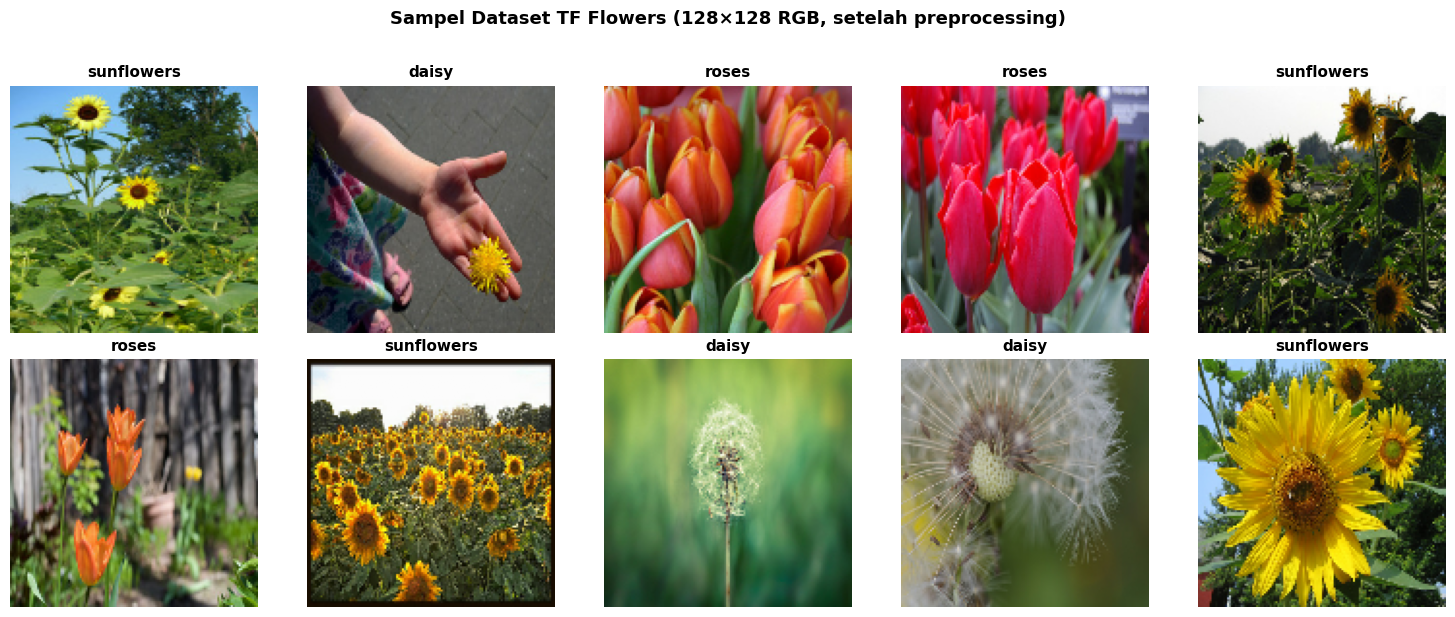

In [5]:
# Visualisasi sampel gambar dari dataset (setelah preprocessing)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for idx, (image, label) in enumerate(ds_train_proc.take(10)):
    ax = axes[idx // 5][idx % 5]
    ax.imshow(image.numpy())
    ax.set_title(CLASS_NAMES[label.numpy()], fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sampel Dataset TF Flowers (128×128 RGB, setelah preprocessing)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

---
## Task 1: Rancangan Arsitektur CNN

Arsitektur CNN yang dirancang terdiri dari **3 blok konvolusi** diikuti oleh **fully-connected layers**:

```
INPUT (128×128×3)
    │
    ├─ BLOCK 1 ─ Conv2D(32, 3×3, ReLU) → Conv2D(32, 3×3, ReLU) → MaxPool(2×2) → BN
    │
    ├─ BLOCK 2 ─ Conv2D(64, 3×3, ReLU) → Conv2D(64, 3×3, ReLU) → MaxPool(2×2) → BN
    │
    ├─ BLOCK 3 ─ Conv2D(128,3×3, ReLU) → Conv2D(128,3×3, ReLU) → MaxPool(2×2) → BN
    │
    ├─ Flatten
    │
    ├─ Dense(256, ReLU) → Dropout(0.5)
    ├─ Dense(128, ReLU) → Dropout(0.3)
    │
    └─ OUTPUT: Dense(3, Softmax)
```

---
## Task 2: Implementasi Arsitektur CNN

Arsitektur mencakup semua komponen yang disyaratkan:

| Komponen | Layer yang Digunakan |
|---|---|
| a. Convolution Layer | `Conv2D` |
| b. Activation Function | `ReLU` (hidden), `Softmax` (output) |
| c. Pooling Layer | `MaxPooling2D` |
| d. Flatten Layer | `Flatten` |
| e. Dense Layer | `Dense(256)`, `Dense(128)` |
| f. Output Layer | `Dense(3, activation='softmax')` |

In [6]:
def build_cnn_model(num_classes, input_shape=(128, 128, 3)):
    """
    Arsitektur CNN untuk klasifikasi gambar.
    
    Komponen wajib:
      a. Convolution Layer  → Conv2D
      b. Activation Function → ReLU (hidden layers), Softmax (output)
      c. Pooling Layer       → MaxPooling2D
      d. Flatten Layer       → Flatten
      e. Dense Layer         → Dense(256), Dense(128)
      f. Output Layer        → Dense(num_classes, softmax)
    """
    model = models.Sequential(name='CNN_FlowerClassifier')

    # ══════════════════════════════════════════════════
    # BLOCK 1 — Fitur level rendah (tepi, tekstur dasar)
    # ══════════════════════════════════════════════════
    # a. Convolution Layer + b. Activation Function (ReLU)
    model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                            input_shape=input_shape, name='conv1_1'))
    model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                            name='conv1_2'))
    # c. Pooling Layer
    model.add(layers.MaxPooling2D((2, 2), name='pool1'))  # 128→64
    model.add(layers.BatchNormalization(name='bn1'))
    model.add(layers.Dropout(0.25, name='drop1'))

    # ══════════════════════════════════════════════════
    # BLOCK 2 — Fitur level menengah (bentuk, pola)
    # ══════════════════════════════════════════════════
    # a. Convolution Layer + b. Activation Function (ReLU)
    model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                            name='conv2_1'))
    model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                            name='conv2_2'))
    # c. Pooling Layer
    model.add(layers.MaxPooling2D((2, 2), name='pool2'))  # 64→32
    model.add(layers.BatchNormalization(name='bn2'))
    model.add(layers.Dropout(0.25, name='drop2'))

    # ══════════════════════════════════════════════════
    # BLOCK 3 — Fitur level tinggi (objek kompleks)
    # ══════════════════════════════════════════════════
    # a. Convolution Layer + b. Activation Function (ReLU)
    model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu',
                            name='conv3_1'))
    model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu',
                            name='conv3_2'))
    # c. Pooling Layer
    model.add(layers.MaxPooling2D((2, 2), name='pool3'))  # 32→16
    model.add(layers.BatchNormalization(name='bn3'))
    model.add(layers.Dropout(0.4, name='drop3'))

    # ══════════════════════════════════════════════════
    # d. FLATTEN LAYER
    # ══════════════════════════════════════════════════
    model.add(layers.Flatten(name='flatten'))  # 16×16×128 = 32.768 neuron

    # ══════════════════════════════════════════════════
    # e. DENSE LAYER
    # ══════════════════════════════════════════════════
    model.add(layers.Dense(256, activation='relu', name='dense1'))
    model.add(layers.Dropout(0.5, name='drop4'))
    model.add(layers.Dense(128, activation='relu', name='dense2'))
    model.add(layers.Dropout(0.3, name='drop5'))

    # ══════════════════════════════════════════════════
    # f. OUTPUT LAYER
    # ══════════════════════════════════════════════════
    # b. Activation Function: Softmax untuk klasifikasi multi-kelas
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))

    return model


# Bangun model
model = build_cnn_model(NUM_CLASSES)
print("Model berhasil dibangun!")

c:\Users\wizfi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model berhasil dibangun!


In [7]:
# ─── Tabel Parameter Model (NB: dijalankan hingga tabel parameter muncul) ───
model.summary()

Model: "CNN_FlowerClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop4 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop5 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,710,051 (33.23 MB)

 Trainable params: 8,709,603 (33.22 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
# Visualisasi diagram arsitektur model (opsional, butuh graphviz di sistem)
import os, io, contextlib, subprocess, sys

# Install pydot jika belum ada
try:
    import pydot
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pydot"],
                          stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

arch_generated = False
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    try:
        from tensorflow.keras.utils import plot_model
        plot_model(model, to_file='model_architecture.png',
                   show_shapes=True, show_layer_names=True,
                   rankdir='TB', expand_nested=True, dpi=80)
        arch_generated = os.path.exists('model_architecture.png')
    except Exception:
        pass

if arch_generated:
    from IPython.display import Image as IPImage
    display(IPImage('model_architecture.png'))
    print("✔ Diagram arsitektur tersimpan: model_architecture.png")
else:
    print("Info: diagram grafis dilewati (graphviz belum terinstall di sistem).")
    print("Arsitektur model sudah ditampilkan via model.summary() di atas.")


Info: diagram grafis dilewati (graphviz belum terinstall di sistem).
Arsitektur model sudah ditampilkan via model.summary() di atas.


## 5. Kompilasi dan Training Model

In [9]:
# Kompilasi model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Konfigurasi training:")
print("  Optimizer   : Adam  (learning_rate = 0.001)")
print("  Loss        : Sparse Categorical Crossentropy")
print("  Metrics     : Accuracy")
print("  Callbacks   : EarlyStopping (patience=10), ReduceLROnPlateau (patience=5)")

Konfigurasi training:
  Optimizer   : Adam  (learning_rate = 0.001)
  Loss        : Sparse Categorical Crossentropy
  Metrics     : Accuracy
  Callbacks   : EarlyStopping (patience=10), ReduceLROnPlateau (patience=5)


In [10]:
EPOCHS = 30

print(f"Memulai training selama maksimal {EPOCHS} epoch...")
history = model.fit(
    ds_train_final,
    validation_data=ds_val_final,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Memulai training selama maksimal 30 epoch...
Epoch 1/30


     53/Unknown 45s 764ms/step - accuracy: 0.5183 - loss: 2.6324

c:\Users\wizfi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


53/53 ━━━━━━━━━━━━━━━━━━━━ 48s 820ms/step - accuracy: 0.5468 - loss: 2.4007 - val_accuracy: 0.4095 - val_loss: 1.1663 - learning_rate: 0.0010
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 772ms/step - accuracy: 0.5510 - loss: 1.4269 - val_accuracy: 0.3426 - val_loss: 1.3862 - learning_rate: 0.0010
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 39s 742ms/step - accuracy: 0.5802 - loss: 1.0759 - val_accuracy: 0.3928 - val_loss: 1.4319 - learning_rate: 0.0010
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 39s 742ms/step - accuracy: 0.6685 - loss: 0.9328 - val_accuracy: 0.3788 - val_loss: 1.5285 - learning_rate: 0.0010
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 40s 752ms/step - accuracy: 0.6750 - loss: 0.9588 - val_accuracy: 0.4011 - val_loss: 1.9571 - learning_rate: 0.0010
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.6752 - loss: 0.8598
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
53/53 ━━━━━━━━━━━━━━━━━━━━ 40s 745ms/step - accuracy: 0.6696 - loss: 0.8676 - val_ac

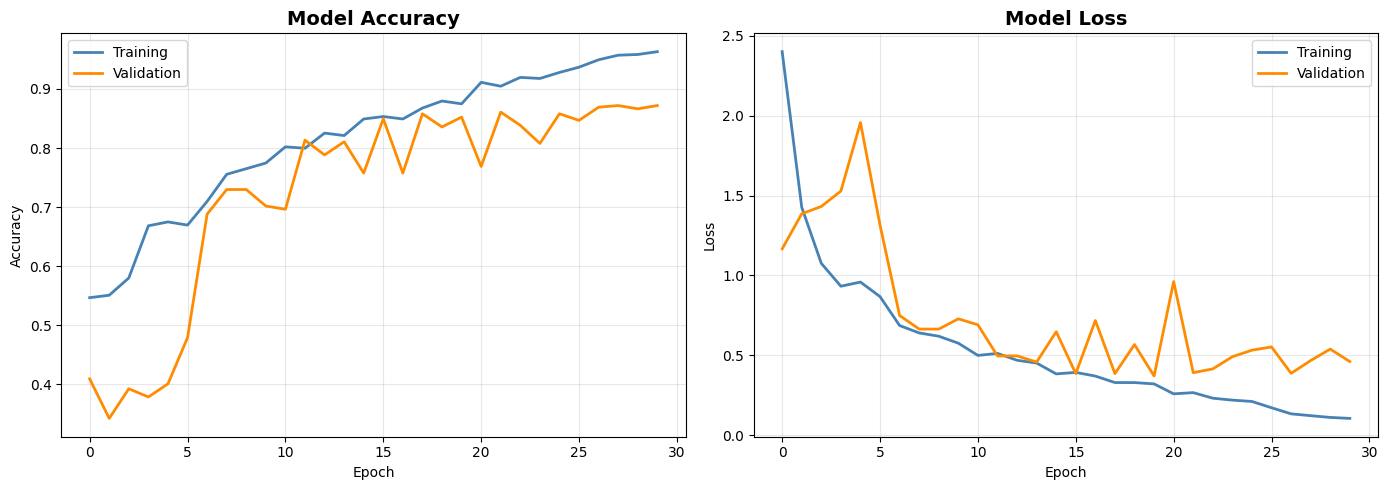

In [11]:
# Plot kurva Accuracy dan Loss
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Training',   color='steelblue',  linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation', color='darkorange', linewidth=2)
    axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Training',   color='steelblue',  linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation', color='darkorange', linewidth=2)
    axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=100, bbox_inches='tight')
    plt.show()

plot_history(history)

In [12]:
# Evaluasi pada test set
test_loss, test_acc = model.evaluate(ds_test_final, verbose=0)

print("=" * 45)
print(f" Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f" Test Loss     : {test_loss:.4f}")
print("=" * 45)

 Test Accuracy : 0.8833  (88.33%)
 Test Loss     : 0.4545


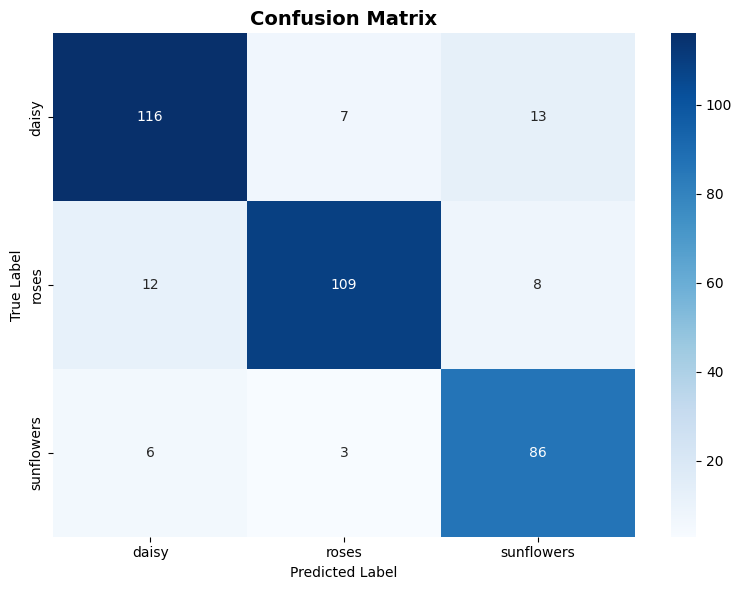


Classification Report:
              precision    recall  f1-score   support

       daisy       0.87      0.85      0.86       136
       roses       0.92      0.84      0.88       129
  sunflowers       0.80      0.91      0.85        95

    accuracy                           0.86       360
   macro avg       0.86      0.87      0.86       360
weighted avg       0.87      0.86      0.86       360



In [13]:
# Confusion Matrix & Classification Report
y_pred, y_true = [], []
for images, labels in ds_test_final:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

---
## Task 3: Diskusi dan Alasan Pemilihan Arsitektur CNN

---

### a. Jumlah Filter pada Convolution Layer

| Block | Filter | Alasan |
|-------|--------|--------|
| Block 1 | **32** | Cukup untuk mendeteksi fitur sederhana (tepi, gradien warna) pada layer awal; menjaga komputasi tetap ringan |
| Block 2 | **64** | Dua kali lipat dari block 1 untuk menangkap fitur yang lebih kompleks (tekstur, pola) |
| Block 3 | **128** | Terus berlipat ganda untuk merepresentasikan fitur abstrak tingkat tinggi (bentuk bunga, mahkota, dll.) |

> **Prinsip umum:** Jumlah filter digandakan setiap kali resolusi spasial diperkecil oleh pooling, sehingga *capacity* model tetap proporsional meskipun ukuran feature map mengecil.

---

### b. Ukuran Kernel (3 × 3)

Kernel **3 × 3** dipilih karena:
- **Efisiensi komputasi** — Ukuran terkecil yang masih dapat menangkap pola spasial 2D
- **Representasi ekuivalen** — Dua layer Conv(3×3) memiliki receptive field setara Conv(5×5), namun dengan parameter lebih sedikit dan satu tambahan ReLU
- **Umum digunakan** — Menjadi standar de-facto sejak VGGNet (Simonyan & Zisserman, 2014)
- **padding='same'** digunakan agar ukuran output sama dengan input, sehingga informasi tepi gambar tidak hilang

---

### c. Jenis Pooling (MaxPooling 2 × 2)

**MaxPooling 2 × 2** dipilih karena:
- **Reduksi dimensi** — Menurunkan resolusi spasial ½ × ½, mengurangi jumlah parameter dan komputasi
- **Invariansi translasi** — Mempertahankan fitur dominan (nilai maksimum) meskipun ada sedikit pergeseran posisi pada gambar
- **Mencegah overfitting** — Mengurangi ukuran feature map memaksa model belajar representasi yang lebih general
- Dibandingkan *AveragePooling*, MaxPooling lebih baik untuk tugas klasifikasi karena aktivasi terkuat (paling representatif) yang dipertahankan

---

### d. Fungsi Aktivasi

| Layer | Fungsi | Alasan |
|-------|--------|--------|
| Conv & Dense | **ReLU** (`f(x) = max(0, x)`) | Mengatasi *vanishing gradient*; komputasi cepat; tidak saturasi untuk nilai positif; performa terbukti baik di CNN |
| Output Layer | **Softmax** | Mengubah logit menjadi distribusi probabilitas yang berjumlah 1.0 — tepat untuk klasifikasi *multi-class* |

> **Mengapa bukan Sigmoid?** Sigmoid menghasilkan probabilitas independen per kelas (cocok untuk multi-label), sedangkan Softmax memastikan total probabilitas = 1 (cocok untuk multi-class single-label seperti kasus ini).

---

### e. Jumlah Neuron pada Output Layer

Output layer menggunakan **3 neuron** karena:
- Dataset yang digunakan memiliki tepat **3 kelas**: *daisy, roses, sunflowers*
- Setiap neuron merepresentasikan probabilitas gambar termasuk dalam kelas yang bersangkutan
- Prediksi akhir diambil dengan `argmax` dari 3 nilai probabilitas tersebut

$$\hat{y} = \arg\max_{i \in \{0,1,2\}} \text{softmax}(z_i)$$

---

### Ringkasan Arsitektur

| Komponen | Pilihan | Justifikasi Singkat |
|----------|---------|---------------------|
| Filter | 32 → 64 → 128 | Hierarki fitur rendah ke tinggi |
| Kernel size | 3 × 3 | Efisien, standar industri |
| Pooling | MaxPooling 2×2 | Mempertahankan fitur dominan, reduksi dimensi |
| Aktivasi (hidden) | ReLU | Cepat, hindari vanishing gradient |
| Aktivasi (output) | Softmax | Distribusi probabilitas multi-class |
| Neuron output | 3 | Sesuai jumlah kelas dataset (daisy, roses, sunflowers) |
| Regularisasi | Dropout + BatchNorm | Mencegah overfitting |

---
## 6. Simpan Hasil & Generate Report

In [14]:
import json, os, shutil
from datetime import datetime
from sklearn.metrics import classification_report

# ── Folder project ─────────────────────────────────────────────────────────
PROJECT_DIR = os.path.dirname(os.path.abspath("cnn_image_classification.ipynb"))
# Fallback: hardcode path jika __file__ tidak tersedia di notebook
PROJECT_DIR = r"d:\Unpam\semester 5\Machine Learning\pert-15"
OUTPUT_DIR  = os.path.join(PROJECT_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 1. Simpan model ─────────────────────────────────────────────────────────
model.save(os.path.join(OUTPUT_DIR, "cnn_flower_model.h5"))
print("✔ Model            →", os.path.join(OUTPUT_DIR, "cnn_flower_model.h5"))

# ── 2. Model summary ────────────────────────────────────────────────────────
summary_lines = []
model.summary(print_fn=lambda x: summary_lines.append(x))
with open(os.path.join(OUTPUT_DIR, "model_summary.txt"), "w", encoding="utf-8") as f:
    f.write("\n".join(summary_lines))
print("✔ Model summary    →", os.path.join(OUTPUT_DIR, "model_summary.txt"))

# ── 3. Training history ─────────────────────────────────────────────────────
history_data = {k: [float(v) for v in vals] for k, vals in history.history.items()}
with open(os.path.join(OUTPUT_DIR, "training_history.json"), "w", encoding="utf-8") as f:
    json.dump(history_data, f, indent=2)
print("✔ Training history →", os.path.join(OUTPUT_DIR, "training_history.json"))

# ── 4. Classification report ────────────────────────────────────────────────
report_str = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
with open(os.path.join(OUTPUT_DIR, "classification_report.txt"), "w", encoding="utf-8") as f:
    f.write(report_str)
print("✔ Class. report    →", os.path.join(OUTPUT_DIR, "classification_report.txt"))

# ── 5. Salin PNG ke outputs/ ────────────────────────────────────────────────
for png in ["sample_images.png", "training_history.png",
            "confusion_matrix.png", "model_architecture.png"]:
    src = os.path.join(PROJECT_DIR, png)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(OUTPUT_DIR, png))
        print(f"✔ {png:<28} → outputs/{png}")

# ── 6. Metrics summary ──────────────────────────────────────────────────────
best_val_acc  = max(history.history["val_accuracy"])
best_val_loss = min(history.history["val_loss"])
final_epoch   = len(history.history["accuracy"])

metrics_summary = {
    "tanggal"       : datetime.now().strftime("%Y-%m-%d %H:%M"),
    "dataset"       : "TensorFlow Flowers (3 kelas: daisy, roses, sunflowers)",
    "total_gambar"  : TOTAL_IMAGES,
    "n_train"       : n_train,
    "n_val"         : n_val,
    "n_test"        : TOTAL_IMAGES - n_train - n_val,
    "epochs_ran"    : final_epoch,
    "best_val_acc"  : round(best_val_acc,  4),
    "best_val_loss" : round(best_val_loss, 4),
    "test_accuracy" : round(test_acc,  4),
    "test_loss"     : round(test_loss, 4),
}
with open(os.path.join(OUTPUT_DIR, "metrics_summary.json"), "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, indent=2)
print("✔ Metrics summary  →", os.path.join(OUTPUT_DIR, "metrics_summary.json"))

print("\n=== Ringkasan Metrik ===")
for k, v in metrics_summary.items():
    print(f"  {k:<18}: {v}")

✔ Model            → d:\Unpam\semester 5\Machine Learning\pert-15\outputs\cnn_flower_model.h5


✔ Model summary    → d:\Unpam\semester 5\Machine Learning\pert-15\outputs\model_summary.txt
✔ Training history → d:\Unpam\semester 5\Machine Learning\pert-15\outputs\training_history.json
✔ Class. report    → d:\Unpam\semester 5\Machine Learning\pert-15\outputs\classification_report.txt
✔ sample_images.png            → outputs/sample_images.png
✔ training_history.png         → outputs/training_history.png
✔ confusion_matrix.png         → outputs/confusion_matrix.png
✔ Metrics summary  → d:\Unpam\semester 5\Machine Learning\pert-15\outputs\metrics_summary.json

=== Ringkasan Metrik ===
  tanggal           : 2026-05-28 00:15
  dataset           : TensorFlow Flowers (3 kelas: daisy, roses, sunflowers)
  total_gambar      : 2396
  n_train           : 1677
  n_val             : 359
  n_test            : 360
  epochs_ran        : 30
  best_val_acc      : 0.8719
  best_val_loss     : 0.3709
  test_accuracy     : 0.8833
  test_loss         : 0.4545


In [15]:
# ── Generate laporan_cnn.md ─────────────────────────────────────────────────
REPORT_PATH = os.path.join(PROJECT_DIR, "laporan_cnn.md")

report_md = f"""# Laporan CNN Image Classification
**Mata Kuliah:** Machine Learning — Pertemuan 15  
**Tanggal:** {metrics_summary['tanggal']}

---

## 1. Dataset

| Atribut | Nilai |
|---------|-------|
| Nama | TensorFlow Flowers |
| Sumber | https://www.tensorflow.org/datasets/catalog/tf_flowers |
| Kelas | daisy, roses, sunflowers |
| Jumlah kelas | 3 |
| Total gambar (3 kelas) | {metrics_summary['total_gambar']} |
| Training (70%) | {metrics_summary['n_train']} gambar |
| Validation (15%) | {metrics_summary['n_val']} gambar |
| Testing (15%) | {metrics_summary['n_test']} gambar |
| Ukuran input | 128 × 128 piksel (RGB) |

---

## 2. Preprocessing

- **Resize**: semua gambar diubah ke **128 × 128 piksel**
- **Normalisasi**: nilai piksel dibagi 255 → rentang `[0.0, 1.0]`
- **Augmentasi** (training only): random flip horizontal & vertikal, brightness, contrast, saturation

---

## 3. Arsitektur CNN (Task 1 & 2)

```
INPUT (128×128×3)
    │
    ├─ BLOCK 1 ─ Conv2D(32, 3×3, ReLU) × 2 → MaxPool(2×2) → BatchNorm → Dropout(0.25)
    ├─ BLOCK 2 ─ Conv2D(64, 3×3, ReLU) × 2 → MaxPool(2×2) → BatchNorm → Dropout(0.25)
    ├─ BLOCK 3 ─ Conv2D(128,3×3, ReLU) × 2 → MaxPool(2×2) → BatchNorm → Dropout(0.40)
    ├─ Flatten
    ├─ Dense(256, ReLU) → Dropout(0.5)
    ├─ Dense(128, ReLU) → Dropout(0.3)
    └─ OUTPUT: Dense(3, Softmax)
```

| Komponen | Layer |
|----------|-------|
| a. Convolution Layer | `Conv2D` |
| b. Activation Function | `ReLU` (hidden), `Softmax` (output) |
| c. Pooling Layer | `MaxPooling2D(2×2)` |
| d. Flatten Layer | `Flatten` |
| e. Dense Layer | `Dense(256)`, `Dense(128)` |
| f. Output Layer | `Dense(3, softmax)` |

Tabel parameter lengkap: lihat `outputs/model_summary.txt`

---

## 4. Training

| Parameter | Nilai |
|-----------|-------|
| Optimizer | Adam (lr = 0.001) |
| Loss | Sparse Categorical Crossentropy |
| Epochs (max) | 30 |
| Epochs berjalan | {metrics_summary['epochs_ran']} |
| Early Stopping | patience = 10 (monitor: val_accuracy) |
| ReduceLROnPlateau | patience = 5, factor = 0.5 |

![Training History](outputs/training_history.png)

---

## 5. Hasil Evaluasi

| Metrik | Nilai |
|--------|-------|
| Best Val Accuracy | **{metrics_summary['best_val_acc']:.4f}** ({metrics_summary['best_val_acc']*100:.2f}%) |
| Best Val Loss | {metrics_summary['best_val_loss']:.4f} |
| **Test Accuracy** | **{metrics_summary['test_accuracy']:.4f}** ({metrics_summary['test_accuracy']*100:.2f}%) |
| **Test Loss** | **{metrics_summary['test_loss']:.4f}** |

### Confusion Matrix

![Confusion Matrix](outputs/confusion_matrix.png)

### Classification Report

```
{report_str}
```

---

## 6. Diskusi Arsitektur (Task 3)

### a. Jumlah Filter Convolution Layer

| Block | Filter | Alasan |
|-------|--------|--------|
| Block 1 | 32 | Fitur level rendah (tepi, tekstur); komputasi ringan |
| Block 2 | 64 | Fitur menengah (bentuk, pola); kapasitas meningkat |
| Block 3 | 128 | Fitur abstrak tinggi; digandakan setiap pooling |

### b. Ukuran Kernel: 3 × 3

- Efisien secara komputasi — terkecil yang dapat menangkap pola spasial 2D
- Dua Conv(3×3) setara receptive field Conv(5×5) dengan parameter lebih sedikit
- Standar industri sejak VGGNet (2014); `padding='same'` menjaga ukuran feature map

### c. Jenis Pooling: MaxPooling 2 × 2

- Reduksi dimensi ½×½ per block
- Mempertahankan fitur dominan (nilai maksimum) — lebih baik dari AveragePooling untuk klasifikasi
- Memberikan invariansi translasi terhadap pergeseran kecil pada gambar

### d. Fungsi Aktivasi

| Layer | Fungsi | Alasan |
|-------|--------|--------|
| Conv & Dense | ReLU | Hindari vanishing gradient; komputasi cepat |
| Output | Softmax | Distribusi probabilitas multi-class (total = 1.0) |

### e. Jumlah Neuron Output Layer: 3

Dataset memiliki 3 kelas (daisy, roses, sunflowers), sehingga output layer menggunakan **3 neuron** dengan Softmax.

$$\\hat{{y}} = \\arg\\max_{{i \\in \\{{0,1,2\\}}}} \\text{{softmax}}(z_i)$$

---

## 7. File Output

| File | Keterangan |
|------|-----------|
| `outputs/cnn_flower_model.h5` | Model tersimpan |
| `outputs/model_summary.txt` | Tabel parameter model |
| `outputs/training_history.json` | History accuracy & loss per epoch |
| `outputs/metrics_summary.json` | Ringkasan metrik evaluasi |
| `outputs/classification_report.txt` | Precision, recall, F1 per kelas |
| `outputs/training_history.png` | Kurva training/validation |
| `outputs/confusion_matrix.png` | Confusion matrix test set |
| `outputs/sample_images.png` | Sampel gambar dataset |
"""

with open(REPORT_PATH, "w", encoding="utf-8") as f:
    f.write(report_md)

print(f"✔ laporan_cnn.md tersimpan → {REPORT_PATH}")
print(f"  Jumlah baris             : {len(report_md.splitlines())}")

✔ laporan_cnn.md tersimpan → d:\Unpam\semester 5\Machine Learning\pert-15\laporan_cnn.md
  Jumlah baris             : 151
